Dataset loaded successfully
Original shape: (4564, 96)

After cleaning:
X shape: (4564, 92)
y shape: (4564,)

Running RFE with Ridge...

TOP 20 FEATURES SELECTED BY RFE
 1. MagpieData maximum Row
 2. MagpieData mean Row
 3. MagpieData maximum Electronegativity
 4. MagpieData range Electronegativity
 5. MagpieData mode Electronegativity
 6. MagpieData maximum NsValence
 7. MagpieData maximum NpValence
 8. MagpieData mode NsUnfilled
 9. MagpieData minimum NpUnfilled
10. MagpieData mean NpUnfilled
11. MagpieData avg_dev NpUnfilled
12. MagpieData minimum NdUnfilled
13. MagpieData maximum NdUnfilled
14. MagpieData mean NdUnfilled
15. MagpieData minimum NUnfilled
16. MagpieData range NUnfilled
17. MagpieData avg_dev NUnfilled
18. MagpieData maximum GSmagmom
19. MagpieData range GSmagmom
20. MagpieData mean GSmagmom

Running Random Forest...

RANDOM FOREST FEATURE IMPORTANCE
                             Feature   Importance
                 MagpieData mean Row 4.245770e-01
MagpieData maximum 

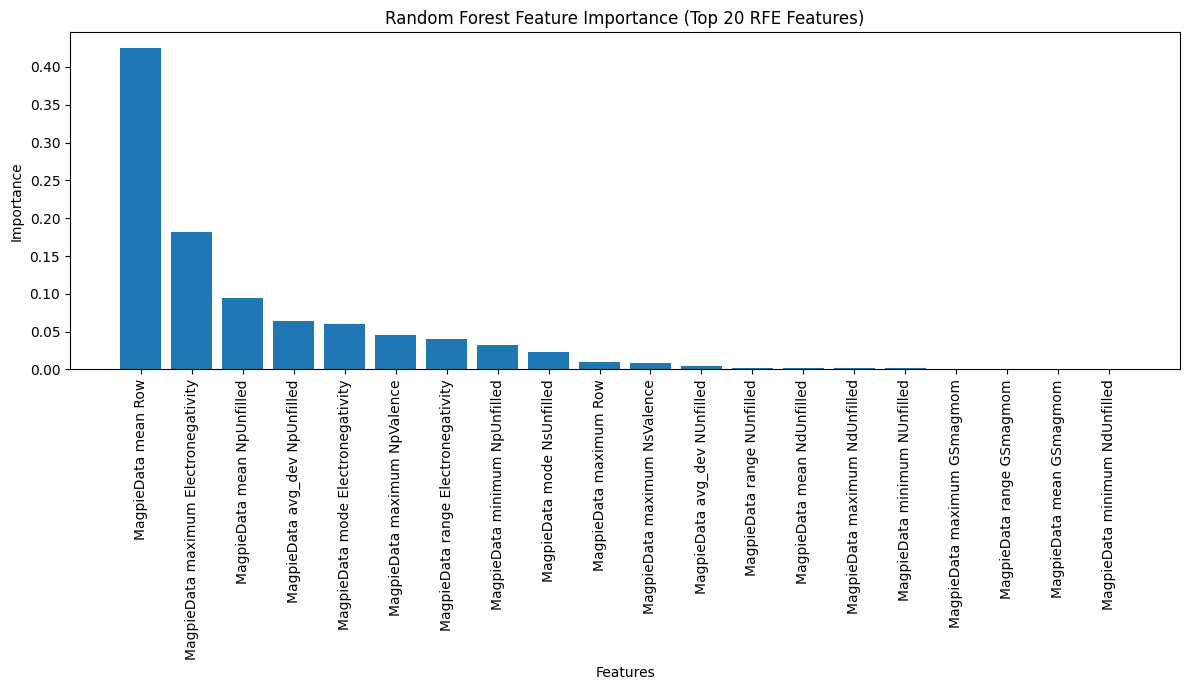


✅ PROCESS COMPLETED SUCCESSFULLY

Target: MagpieData mean GSbandgap
Selected features: 20
Final curated dataset shape: (4564, 21)

Output file:
curated_features_s21.csv

Feature importance file:
rfe_random_forest_importance_s21.csv


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_selection import RFE
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

df = pd.read_csv("filtered_features_s20.csv")

print("Dataset loaded successfully")
print("Original shape:", df.shape)


target_column = "MagpieData mean GSbandgap"

if target_column not in df.columns:
    raise ValueError(
        f"Target column '{target_column}' was not found."
    )

# Target
y = pd.to_numeric(
    df[target_column],
    errors="coerce"
)

target_related_columns = [
    "MagpieData minimum GSbandgap",
    "MagpieData maximum GSbandgap",
    "MagpieData mean GSbandgap",
    "MagpieData mode GSbandgap"
]

# Only remove columns that actually exist
columns_to_remove = [
    col for col in target_related_columns
    if col in df.columns
]

# Also remove formula if present
if "formula" in df.columns:
    columns_to_remove.append("formula")

X = df.drop(
    columns=columns_to_remove,
    errors="ignore"
)


X = X.apply(
    pd.to_numeric,
    errors="coerce"
)

# Replace infinity
X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

# Remove completely empty columns
X = X.dropna(
    axis=1,
    how="all"
)

# Fill missing values using median
X = X.fillna(
    X.median(numeric_only=True)
)


valid_rows = y.notna()

X = X.loc[
    valid_rows
].reset_index(drop=True)

y = y.loc[
    valid_rows
].reset_index(drop=True)

print("\nAfter cleaning:")
print("X shape:", X.shape)
print("y shape:", y.shape)


if X.shape[1] < 20:
    raise ValueError(
        f"Only {X.shape[1]} usable features are available. "
        "At least 20 features are required for selecting top 20."
    )


print("\nRunning RFE with Ridge...")

ridge = Ridge(
    alpha=1.0
)

rfe = RFE(
    estimator=ridge,
    n_features_to_select=20,
    step=1
)

# Fit RFE
rfe.fit(
    X,
    y
)

# Transform dataset
X_rfe = rfe.transform(
    X
)


top_features = X.columns[
    rfe.support_
]

print("\n==========================================")
print("TOP 20 FEATURES SELECTED BY RFE")
print("==========================================")

for i, feature in enumerate(
    top_features,
    start=1
):
    print(
        f"{i:2d}. {feature}"
    )


print("\nRunning Random Forest...")

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_rfe,
    y
)

# Feature importance
importances = rf.feature_importances_

# Sort descending
indices = np.argsort(
    importances
)[::-1]


importance_df = pd.DataFrame({
    "Feature": top_features,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("\n==========================================")
print("RANDOM FOREST FEATURE IMPORTANCE")
print("==========================================")

print(
    importance_df.to_string(
        index=False
    )
)



plt.figure(
    figsize=(12, 7)
)

plt.bar(
    range(len(importances)),
    importances[indices],
    align="center"
)

plt.xticks(
    range(len(importances)),
    top_features[indices],
    rotation=90
)

plt.title(
    "Random Forest Feature Importance "
    "(Top 20 RFE Features)"
)

plt.xlabel(
    "Features"
)

plt.ylabel(
    "Importance"
)

plt.tight_layout()

plt.show()


# Keep formula if it exists
final_columns = []

if "formula" in df.columns:
    final_columns.append(
        "formula"
    )

# Keep target
final_columns.append(
    target_column
)

# Add selected features
final_columns.extend(
    list(top_features)
)

# Create curated dataframe
df_curated = df.loc[
    valid_rows,
    final_columns
].reset_index(drop=True)


df_curated.to_csv(
    "curated_features_s21.csv",
    index=False
)

# Save importance separately
importance_df.to_csv(
    "rfe_random_forest_importance_s21.csv",
    index=False
)


print("\n==========================================")
print("✅ PROCESS COMPLETED SUCCESSFULLY")
print("==========================================")

print(
    "\nTarget:",
    target_column
)

print(
    "Selected features:",
    len(top_features)
)

print(
    "Final curated dataset shape:",
    df_curated.shape
)

print(
    "\nOutput file:"
)

print(
    "curated_features_s21.csv"
)

print(
    "\nFeature importance file:"
)

print(
    "rfe_random_forest_importance_s21.csv"
)